# HAL-TMLE for the Right-Censored Mean

This notebook demos the package API for the scalar mean target under right censoring.

Locked design choices:
- fit one reverse Kaplan-Meier for censoring and reuse it for IPCW weights and TMLE;
- keep the initial estimator as the existing IPCW-weighted HAL density fit;
- target the bounded mean on `[0, 1]`, equivalently the restricted mean survival time at `tau = 1`;
- compare the CV-IPCW plug-in mean, TMLE with estimated KM censoring (no cheating), TMLE with oracle censoring (cheating), and an event-time KM integral benchmark;
- use a compact parallel Monte Carlo sweep with conservative defaults that can be scaled up.


In [1]:
from __future__ import annotations

from contextlib import contextmanager
from pathlib import Path
import os
import sys
import time
from typing import Any

# Keep parallel solver demos from over-subscribing local CPUs.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed
from tqdm import tqdm

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "pyproject.toml").exists() and (p / "src").exists()
)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from haldensity.censoring.right.estimators import RightCensoredInitEstimator
from haldensity.censoring.right.km import KaplanMeier
from haldensity.censoring.right.weights import compute_ipcw_weights
from haldensity.censoring.tuners.right_tuners import RightCensoredInitTuner
from haldensity.targeting import right_censored_mean_targeting_M_step
from haldensity.utils import TruncatedGMM

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

REPRESENTATIVE_SEED = 7
N = 200
TAU = 1.0

REFERENCE_GMM = {
    "components": [
        {"mean": 0.25, "std": 0.07, "lower": 0.0, "upper": 1.0},
        {"mean": 0.65, "std": 0.10, "lower": 0.0, "upper": 1.0},
    ],
    "weights": [0.45, 0.55],
}
CENSOR_LOW = 0.0
CENSOR_HIGH = 1.0
ORACLE_CENSORING_GRID_SIZE = 2000

GBAR_CLIP = 1e-6
SURVIVAL_CLIP = 1e-8
TMLE_MODE = "iterative"  # one of {"one_step", "iterative", "auto"}
TMLE_MAX_ITER = 10
ONE_STEP_EIF_GATE = 1e-8

# The default notebook path is fast and deterministic. Set this to True to mirror
# the CV-tuned Stage 1 workflow from the survival notebook more closely.
FIT_STAGE1_WITH_CV = True
CV_FOLDS = 5
N_TRIALS = 25
N_GRID_POINTS = 100
FIXED_NORM_CONSTRAINT = 50.0
FIXED_BASIS_ORDER = 1
STAGE1_SOLVER = "ECOS"
STAGE1_TUNING_OVERRIDES = {
    "basis_order": [1],
    "norm_constraint": {"low": 5.0, "high": 200.0, "log": True},
}

SMALL_MC_N_SEEDS = 100
SMALL_MC_SEEDS = list(range(1, SMALL_MC_N_SEEDS + 1))
SMALL_MC_N_WORKERS = 10

run_config = pd.DataFrame([
    {
        "representative_seed": REPRESENTATIVE_SEED,
        "n": N,
        "tau": TAU,
        "dgp": "two-component TruncatedGMM + Uniform censoring",
        "fit_stage1_with_cv": FIT_STAGE1_WITH_CV,
        "cv_folds": CV_FOLDS,
        "n_trials": N_TRIALS,
        "n_grid_points": N_GRID_POINTS,
        "tmle_mode": TMLE_MODE,
        "tmle_max_iter": TMLE_MAX_ITER,
        "small_mc_n_seeds": SMALL_MC_N_SEEDS,
        "small_mc_n_workers": SMALL_MC_N_WORKERS,
        "root": str(ROOT),
    }
])
display(run_config)


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,representative_seed,n,tau,dgp,fit_stage1_with_cv,cv_folds,n_trials,n_grid_points,tmle_mode,tmle_max_iter,small_mc_n_seeds,small_mc_n_workers,root
0,7,200,1.0,two-component TruncatedGMM + Uniform censoring,True,5,25,100,iterative,10,100,10,/Users/houyilong/GitHub/HALDensity


## Estimand and Comparators

The target is the bounded mean event time, `E[T]` on `[0, 1]`. Since the event-time support is bounded, this is also the restricted mean survival time at `tau = 1`:

```text
E[min(T, 1)] = integral_0^1 S_T(t) dt.
```

The package TMLE returns top-level `standard_error`, `estimand_variance`, `ci_lower`, and `ci_upper` using the initial-stage EIC standard error centered at the targeted `mu_star`. The Monte Carlo section keeps that convention when reporting TMLE coverage.


In [2]:
def make_sampler() -> TruncatedGMM:
    return TruncatedGMM(**REFERENCE_GMM)


def true_mean_from_sampler(sampler: TruncatedGMM, *, n_grid: int = 20_001) -> float:
    grid = np.linspace(0.0, TAU, n_grid)
    density = sampler.compute_density(grid)
    mass = np.trapz(density, grid)
    return float(np.trapz(grid * density, grid) / mass)


def simulate_reference_right_censored_dgp(n: int, *, seed: int) -> dict[str, Any]:
    np.random.seed(seed)
    sampler = make_sampler()
    event_time = sampler.generate_samples(n)
    censor_time = np.random.uniform(CENSOR_LOW, CENSOR_HIGH, size=n)
    observed_time = np.minimum(event_time, censor_time)
    delta = (event_time <= censor_time).astype(int)
    data = pd.DataFrame({"T": observed_time, "Delta": delta})
    return {
        "observed_data": data,
        "truth": {
            "mean": true_mean_from_sampler(sampler),
            "density_fn": lambda t, _sampler=sampler: _sampler.compute_density(np.asarray(t, dtype=float)),
            "survival_fn": lambda t, _sampler=sampler: 1.0 - _sampler.compute_cdf(np.asarray(t, dtype=float)),
        },
    }


class UniformCensoringOracle:
    """Known censoring law for cheat mode: C ~ Uniform(low, high)."""

    def __init__(self, *, low: float, high: float, n_grid: int):
        if not high > low:
            raise ValueError("high must be greater than low")
        if n_grid < 2:
            raise ValueError("n_grid must be at least 2")
        self.low = float(low)
        self.high = float(high)
        self.n_grid = int(n_grid)

    def predict(self, t: np.ndarray | float) -> np.ndarray:
        values = np.asarray(t, dtype=float)
        survival = (self.high - values) / (self.high - self.low)
        survival = np.where(values < self.low, 1.0, survival)
        survival = np.where(values >= self.high, 0.0, survival)
        return np.clip(survival, 0.0, 1.0)

    def stepwise_survival_(self) -> tuple[np.ndarray, np.ndarray]:
        # Approximate the continuous uniform dG_C integral without creating
        # an artificial endpoint jump at t=high where Gbar(high)=0.
        jump_times = np.linspace(self.low, self.high, self.n_grid + 1, dtype=float)[1:-1]
        return jump_times, self.predict(jump_times)


def make_censoring_model(data: pd.DataFrame, *, use_oracle_uniform_censoring: bool = False):
    if use_oracle_uniform_censoring:
        return UniformCensoringOracle(
            low=CENSOR_LOW,
            high=CENSOR_HIGH,
            n_grid=ORACLE_CENSORING_GRID_SIZE,
        )
    return KaplanMeier().fit(data, time_col="T", delta_col="Delta")


def event_km_integrated_mean(data: pd.DataFrame, *, tau: float = TAU) -> float:
    """Kaplan-Meier plug-in for event-time RMST, not the repo censoring KM."""
    y = data["T"].to_numpy(dtype=float)
    delta = data["Delta"].to_numpy(dtype=int)
    order = np.argsort(y)
    y_sorted = y[order]
    delta_sorted = delta[order]

    unique_times, idx_start = np.unique(y_sorted, return_index=True)
    counts_at_time = np.diff(np.append(idx_start, len(y_sorted)))
    events_at_time = np.add.reduceat(delta_sorted, idx_start)
    at_risk = len(y_sorted) - np.cumsum(np.append(0, counts_at_time[:-1]))

    area = 0.0
    previous_time = 0.0
    survival_left = 1.0
    for time_value, n_events, risk_count in zip(unique_times, events_at_time, at_risk):
        if time_value > tau:
            break
        area += survival_left * max(float(time_value) - previous_time, 0.0)
        if risk_count > 0:
            survival_left *= max(1.0 - float(n_events) / float(risk_count), 0.0)
        previous_time = float(time_value)

    if previous_time < tau:
        area += survival_left * (tau - previous_time)
    return float(area)


def fit_stage1_ipcw(data: pd.DataFrame, *, seed: int, use_cv: bool = FIT_STAGE1_WITH_CV) -> dict[str, Any]:
    tic = time.perf_counter()
    km = KaplanMeier().fit(data, time_col="T", delta_col="Delta")
    t_vals = data["T"].to_numpy(dtype=float)
    delta_vals = data["Delta"].to_numpy(dtype=int)
    weights = compute_ipcw_weights(
        T=t_vals,
        Delta=delta_vals,
        S_c_predict=lambda t: np.atleast_1d(km.predict(t)),
        clip=GBAR_CLIP,
    )
    uncensored_mask = delta_vals == 1
    if not np.any(uncensored_mask):
        raise RuntimeError("No uncensored event times are available for the IPCW-HAL initializer.")

    if use_cv:
        tuner = RightCensoredInitTuner(
            data=data,
            cv_folds=CV_FOLDS,
            random_state=seed,
            n_grid_points=N_GRID_POINTS,
            param_overrides=STAGE1_TUNING_OVERRIDES,
            use_conservative_adjustment=False,
            validation_metric="observed_loglik",
            clip=GBAR_CLIP,
            silent=True,
        )
        tuning_result = tuner.optimize(n_trials=N_TRIALS)
        norm_constraint = float(tuning_result.best_params["norm_constraint"])
        basis_order = int(tuning_result.best_params["basis_order"])
        best_params = dict(tuning_result.best_params)
    else:
        norm_constraint = float(FIXED_NORM_CONSTRAINT)
        basis_order = int(FIXED_BASIS_ORDER)
        best_params = {"norm_constraint": norm_constraint, "basis_order": basis_order, "source": "fixed"}

    uncensored_df = pd.DataFrame({"W1": t_vals[uncensored_mask]})
    estimator = RightCensoredInitEstimator(
        tol=1e-8,
        norm_constraint=norm_constraint,
        n_grid_points=N_GRID_POINTS,
        basis_order=basis_order,
        solver=STAGE1_SOLVER,
        use_secondary_solver=True,
    )
    estimator.fit(uncensored_df, sample_weights=weights[uncensored_mask])

    gbar_vals = np.asarray(km.predict(t_vals), dtype=float)
    return {
        "estimator": estimator,
        "km": km,
        "weights": weights,
        "best_params": best_params,
        "runtime_seconds": float(time.perf_counter() - tic),
        "diagnostics": {
            "n_uncensored": int(uncensored_mask.sum()),
            "censoring_rate": float(1.0 - delta_vals.mean()),
            "min_positive_ipcw_weight": float(np.min(weights[weights > 0])) if np.any(weights > 0) else float("nan"),
            "max_ipcw_weight": float(np.max(weights)) if weights.size else float("nan"),
            "min_gbar": float(np.min(gbar_vals)) if gbar_vals.size else float("nan"),
            "min_gbar_clipped": float(np.min(np.maximum(gbar_vals, GBAR_CLIP))) if gbar_vals.size else float("nan"),
        },
    }


def run_mean_tmle(
    stage1_fit: dict[str, Any],
    data: pd.DataFrame,
    *,
    store_pointwise_arrays: bool,
    censoring_model: Any | None = None,
) -> dict[str, Any]:
    km_model = stage1_fit["km"] if censoring_model is None else censoring_model
    return right_censored_mean_targeting_M_step(
        initial_estimator=stage1_fit["estimator"],
        observed_data=data,
        km=km_model,
        mode=TMLE_MODE,
        one_step_eif_gate=ONE_STEP_EIF_GATE,
        clip=GBAR_CLIP,
        survival_clip=SURVIVAL_CLIP,
        max_iter=TMLE_MAX_ITER,
        store_pointwise_arrays=store_pointwise_arrays,
    )


def hal_density_mean_from_estimator(estimator: RightCensoredInitEstimator) -> float:
    grid, density = estimator.get_density()
    mass = np.trapz(density, grid)
    return float(np.trapz(grid * density, grid) / mass)


## Representative Seed

This section shows one complete run: simulate data, fit the IPCW-HAL initializer, target the mean, and inspect the diagnostics returned by the package API.


n=200, uncensored=108, censored=92
censoring rate: 46.0%
true bounded mean: 0.4700


/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_28719/1390750345.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mass = np.trapz(density, grid)
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_28719/1390750345.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(grid * density, grid) / mass)


,T,Delta
0,0.109928,0
1,0.215087,1
2,0.218148,1
3,0.155421,0
4,0.254036,1


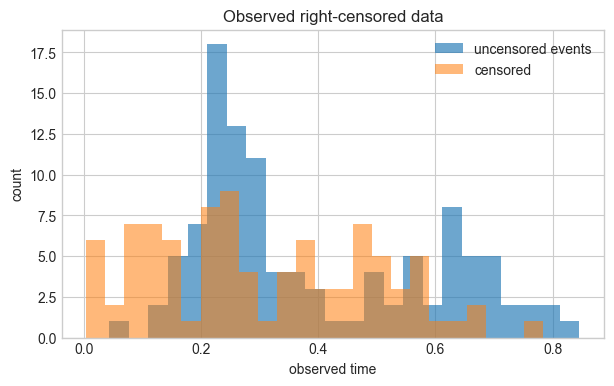

In [3]:
simulation = simulate_reference_right_censored_dgp(n=N, seed=REPRESENTATIVE_SEED)
observed_data = simulation["observed_data"]
truth = simulation["truth"]

print(f"n={len(observed_data)}, uncensored={int(observed_data['Delta'].sum())}, censored={int((1 - observed_data['Delta']).sum())}")
print(f"censoring rate: {1.0 - observed_data['Delta'].mean():.1%}")
print(f"true bounded mean: {truth['mean']:.4f}")
display(observed_data.head())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(observed_data.loc[observed_data["Delta"] == 1, "T"], bins=24, alpha=0.65, label="uncensored events")
ax.hist(observed_data.loc[observed_data["Delta"] == 0, "T"], bins=24, alpha=0.55, label="censored")
ax.set_xlabel("observed time")
ax.set_ylabel("count")
ax.set_title("Observed right-censored data")
ax.legend()
plt.show()


In [4]:
stage1_fit = fit_stage1_ipcw(observed_data, seed=REPRESENTATIVE_SEED)
targeted = run_mean_tmle(stage1_fit, observed_data, store_pointwise_arrays=True)
summary = targeted["summary"].copy()
pointwise_fit = targeted["pointwise_fits"][0]
km_mean = event_km_integrated_mean(observed_data)

comparison = pd.DataFrame([
    {"method": "truth", "estimate": truth["mean"], "error": 0.0},
    {"method": "IPCW-HAL plug-in", "estimate": float(summary.loc[0, "mu_init"]), "error": float(summary.loc[0, "mu_init"] - truth["mean"])},
    {"method": "TMLE mean", "estimate": float(summary.loc[0, "mu_star"]), "error": float(summary.loc[0, "mu_star"] - truth["mean"])},
    {"method": "Event KM integral", "estimate": km_mean, "error": float(km_mean - truth["mean"])},
])

display(pd.DataFrame([stage1_fit["diagnostics"] | stage1_fit["best_params"]]))
display(summary[[
    "mu_init",
    "mu_star",
    "standard_error",
    "standard_error_all_eic",
    "positivity_eic_excluded_count",
    "positivity_eic_excluded_rate",
    "ci_lower",
    "ci_upper",
    "eif_mean_initial_stage",
    "eif_mean_one_step",
    "eif_mean_final",
    "epsilon_last",
    "n_iterations",
    "stop_reason",
    "converged",
]])
display(comparison)
print("KM shared between Stage 1 refit and TMLE layer:", targeted["censoring_cache"]["km"] is stage1_fit["km"])
print("Stage 1 runtime seconds:", round(stage1_fit["runtime_seconds"], 2))


,n_uncensored,censoring_rate,min_positive_ipcw_weight,max_ipcw_weight,min_gbar,min_gbar_clipped,basis_order,norm_constraint
0,108,0.46,1.036269,4.35939,0.22939,0.22939,1,101.23621


,mu_init,mu_star,standard_error,standard_error_all_eic,positivity_eic_excluded_count,positivity_eic_excluded_rate,ci_lower,ci_upper,eif_mean_initial_stage,eif_mean_one_step,eif_mean_final,epsilon_last,n_iterations,stop_reason,converged
0,0.477483,0.476713,0.015583,0.015583,0,0.0,0.446169,0.507256,-0.00068,0.000002,0.000002,-0.013619,1,score_tolerance,True


,method,estimate,error
0,truth,0.469973,0.000000
1,IPCW-HAL plug-in,0.477483,0.007509
2,TMLE mean,0.476713,0.006739
3,Event KM integral,0.478114,0.008141


KM shared between Stage 1 refit and TMLE layer: True
Stage 1 runtime seconds: 2.37


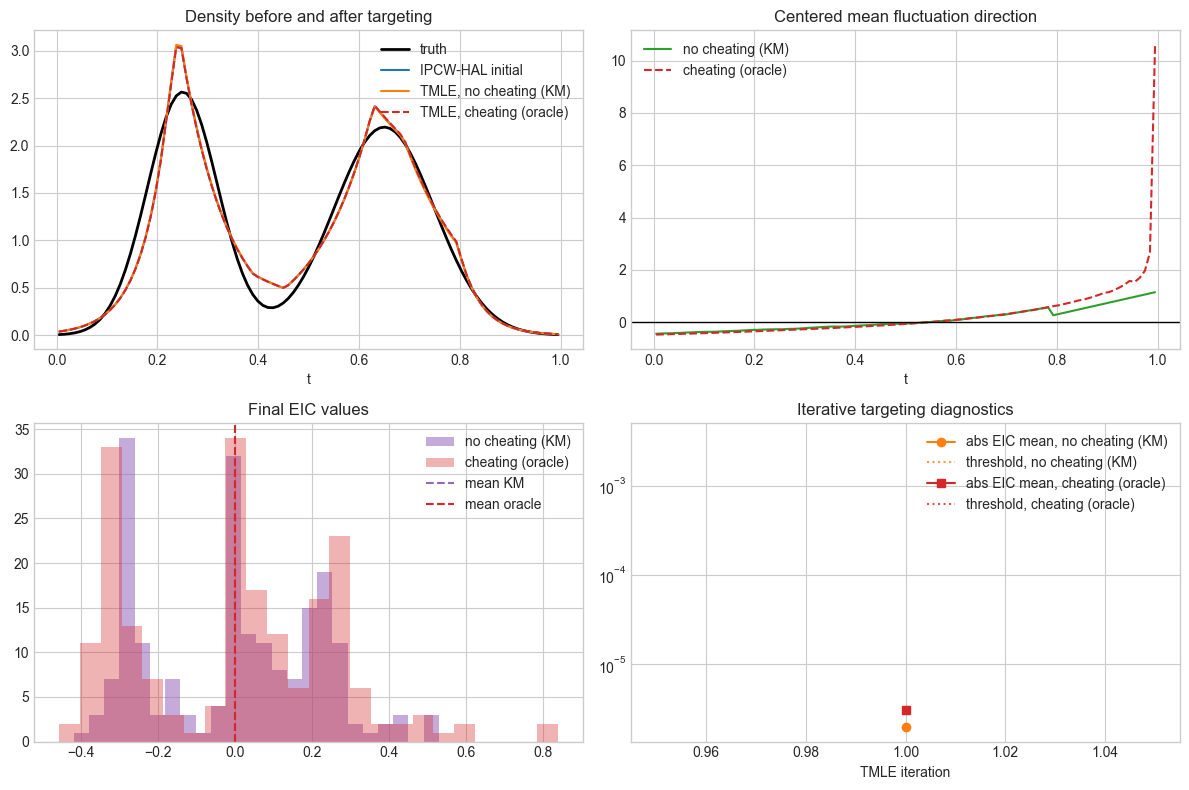

In [5]:
targeted_km = targeted if "targeted" in globals() else run_mean_tmle(stage1_fit, observed_data, store_pointwise_arrays=True)
targeted_oracle = run_mean_tmle(
    stage1_fit,
    observed_data,
    store_pointwise_arrays=True,
    censoring_model=make_censoring_model(observed_data, use_oracle_uniform_censoring=True),
)

pointwise_fit_km = targeted_km["pointwise_fits"][0]
pointwise_fit_oracle = targeted_oracle["pointwise_fits"][0]

grid = np.asarray(pointwise_fit_km["grid_midpoints"], dtype=float)
density_before = np.asarray(pointwise_fit_km["density_before_grid"], dtype=float)
density_after_km = np.asarray(pointwise_fit_km["estimated_density"], dtype=float)
density_after_oracle = np.asarray(pointwise_fit_oracle["estimated_density"], dtype=float)
centered_direction_km = np.asarray(pointwise_fit_km["centered_direction"], dtype=float)
centered_direction_oracle = np.asarray(pointwise_fit_oracle["centered_direction"], dtype=float)
eic_values_km = np.asarray(pointwise_fit_km["eic_values"], dtype=float)
eic_values_oracle = np.asarray(pointwise_fit_oracle["eic_values"], dtype=float)
truth_density = truth["density_fn"](grid)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].plot(grid, truth_density, label="truth", color="black", linewidth=2)
axes[0, 0].plot(grid, density_before, label="IPCW-HAL initial", color="tab:blue")
axes[0, 0].plot(grid, density_after_km, label="TMLE, no cheating (KM)", color="tab:orange")
axes[0, 0].plot(grid, density_after_oracle, label="TMLE, cheating (oracle)", color="tab:red", linestyle="--")
axes[0, 0].set_title("Density before and after targeting")
axes[0, 0].set_xlabel("t")
axes[0, 0].legend()

axes[0, 1].plot(grid, centered_direction_km, color="tab:green", label="no cheating (KM)")
axes[0, 1].plot(grid, centered_direction_oracle, color="tab:red", linestyle="--", label="cheating (oracle)")
axes[0, 1].axhline(0.0, color="black", linewidth=1)
axes[0, 1].set_title("Centered mean fluctuation direction")
axes[0, 1].set_xlabel("t")
axes[0, 1].legend()

axes[1, 0].hist(eic_values_km, bins=24, color="tab:purple", alpha=0.55, label="no cheating (KM)")
axes[1, 0].hist(eic_values_oracle, bins=24, color="tab:red", alpha=0.35, label="cheating (oracle)")
axes[1, 0].axvline(float(np.mean(eic_values_km)), color="tab:purple", linestyle="--", label="mean KM")
axes[1, 0].axvline(float(np.mean(eic_values_oracle)), color="tab:red", linestyle="--", label="mean oracle")
axes[1, 0].set_title("Final EIC values")
axes[1, 0].legend()

for label, pointwise, color, marker in [
    ("no cheating (KM)", pointwise_fit_km, "tab:orange", "o"),
    ("cheating (oracle)", pointwise_fit_oracle, "tab:red", "s"),
]:
    history = pd.DataFrame(pointwise["iteration_history"])
    if len(history):
        if "step" in history.columns:
            x_values = history["step"]
        elif "iteration" in history.columns:
            x_values = history["iteration"]
        else:
            x_values = np.arange(1, len(history) + 1)
        tolerance_column = "threshold" if "threshold" in history.columns else "stop_tolerance"
        axes[1, 1].plot(x_values, history["eif_mean"].abs(), marker=marker, color=color, label=f"abs EIC mean, {label}")
        axes[1, 1].plot(x_values, history[tolerance_column], color=color, linestyle=":", alpha=0.8, label=f"threshold, {label}")

if axes[1, 1].has_data():
    axes[1, 1].set_yscale("log")
    axes[1, 1].set_xlabel("TMLE iteration")
    axes[1, 1].set_title("Iterative targeting diagnostics")
    axes[1, 1].legend()
else:
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Small Parallel Monte Carlo

The sweep below keeps the same estimand and compares four scalar estimators per seed:

- `CV-IPCW plug-in`: the mean of the initial IPCW-HAL density (Stage 1), before targeting.
- `TMLE mean (oracle Gbar / cheating)`: targeting with the known censoring law `Uniform(0, 1)`.
- `TMLE mean (KM / no cheating)`: targeting with estimated reverse KM censoring.
- `Event KM integral`: an event-time Kaplan-Meier RMST estimator, computed by integrating the event survival step function over `[0, 1]`.

Each seed fits Stage 1 once and then reuses that fit for both TMLE variants. The defaults are intentionally small. Increase `SMALL_MC_N_SEEDS`, `SMALL_MC_N_WORKERS`, `N_GRID_POINTS`, and optionally set `FIT_STAGE1_WITH_CV = True` for a more serious run.


In [6]:
@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()


def _mc_result_row(
    *,
    seed: int,
    truth_mean: float,
    method: str,
    score_model: str,
    estimate: float,
    stage1_diagnostics: dict[str, Any],
    stage1_runtime_seconds: float,
    runtime_seconds: float,
    row: pd.Series | None = None,
    pnd_star: float = float("nan"),
) -> dict[str, Any]:
    is_tmle = method.startswith("TMLE")
    if row is None:
        return {
            "seed": int(seed),
            "method": method,
            "score_model": score_model,
            "truth": float(truth_mean),
            "estimate": float(estimate),
            "error": float(estimate - truth_mean),
            "pnd_star": float(pnd_star),
            "tmle_se": float("nan"),
            "tmle_se_all_eic": float("nan"),
            "eic_excluded_count": 0,
            "eic_excluded_rate": 0.0,
            "tmle_ci_lower": float("nan"),
            "tmle_ci_upper": float("nan"),
            "tmle_covered": False,
            "n_iterations": 0,
            "converged": True,
            "censoring_rate": float(stage1_diagnostics["censoring_rate"]),
            "max_ipcw_weight": float(stage1_diagnostics["max_ipcw_weight"]),
            "stage1_runtime_seconds": float(stage1_runtime_seconds),
            "runtime_seconds": float(runtime_seconds),
        }

    final_pnd = float(row["eif_mean_final"]) if is_tmle else float("nan")
    return {
        "seed": int(seed),
        "method": method,
        "score_model": score_model,
        "truth": float(truth_mean),
        "estimate": float(estimate),
        "error": float(estimate - truth_mean),
        "pnd_star": final_pnd if is_tmle else float(pnd_star),
        "tmle_se": float(row["standard_error"]) if is_tmle else float("nan"),
        "tmle_se_all_eic": float(row["standard_error_all_eic"]) if is_tmle else float("nan"),
        "eic_excluded_count": int(row["positivity_eic_excluded_count"]) if is_tmle else 0,
        "eic_excluded_rate": float(row["positivity_eic_excluded_rate"]) if is_tmle else 0.0,
        "tmle_ci_lower": float(row["ci_lower"]) if is_tmle else float("nan"),
        "tmle_ci_upper": float(row["ci_upper"]) if is_tmle else float("nan"),
        "tmle_covered": bool(row["ci_lower"] <= truth_mean <= row["ci_upper"]) if is_tmle else False,
        "n_iterations": int(row["n_iterations"]) if is_tmle else 0,
        "converged": bool(row["converged"]) if is_tmle else True,
        "censoring_rate": float(stage1_diagnostics["censoring_rate"]),
        "max_ipcw_weight": float(stage1_diagnostics["max_ipcw_weight"]),
        "stage1_runtime_seconds": float(stage1_runtime_seconds),
        "runtime_seconds": float(runtime_seconds),
    }


def run_small_mc_seed(seed: int) -> list[dict[str, Any]]:
    tic = time.perf_counter()
    sim = simulate_reference_right_censored_dgp(n=N, seed=seed)
    data_seed = sim["observed_data"]
    truth_mean = float(sim["truth"]["mean"])

    stage1_seed = fit_stage1_ipcw(data_seed, seed=seed)
    stage1_diagnostics = stage1_seed["diagnostics"]

    targeted_km_seed = run_mean_tmle(
        stage1_seed,
        data_seed,
        store_pointwise_arrays=False,
    )
    targeted_oracle_seed = run_mean_tmle(
        stage1_seed,
        data_seed,
        store_pointwise_arrays=False,
        censoring_model=make_censoring_model(data_seed, use_oracle_uniform_censoring=True),
    )

    row_km = targeted_km_seed["summary"].iloc[0]
    row_oracle = targeted_oracle_seed["summary"].iloc[0]
    km_mean_seed = event_km_integrated_mean(data_seed)
    runtime_seconds = float(time.perf_counter() - tic)

    return [
        _mc_result_row(
            seed=seed,
            truth_mean=truth_mean,
            method="CV-IPCW plug-in",
            score_model="KM",
            estimate=float(row_km["mu_init"]),
            row=row_km,
            pnd_star=float(row_km["eif_mean_initial_stage"]),
            stage1_diagnostics=stage1_diagnostics,
            stage1_runtime_seconds=float(stage1_seed["runtime_seconds"]),
            runtime_seconds=runtime_seconds,
        ),
        _mc_result_row(
            seed=seed,
            truth_mean=truth_mean,
            method="TMLE mean (oracle Gbar / cheating)",
            score_model="oracle Uniform(0,1)",
            estimate=float(row_oracle["mu_star"]),
            row=row_oracle,
            stage1_diagnostics=stage1_diagnostics,
            stage1_runtime_seconds=float(stage1_seed["runtime_seconds"]),
            runtime_seconds=runtime_seconds,
        ),
        _mc_result_row(
            seed=seed,
            truth_mean=truth_mean,
            method="TMLE mean (KM / no cheating)",
            score_model="KM",
            estimate=float(row_km["mu_star"]),
            row=row_km,
            stage1_diagnostics=stage1_diagnostics,
            stage1_runtime_seconds=float(stage1_seed["runtime_seconds"]),
            runtime_seconds=runtime_seconds,
        ),
        _mc_result_row(
            seed=seed,
            truth_mean=truth_mean,
            method="Event KM integral",
            score_model="event KM",
            estimate=float(km_mean_seed),
            row=None,
            stage1_diagnostics=stage1_diagnostics,
            stage1_runtime_seconds=float(stage1_seed["runtime_seconds"]),
            runtime_seconds=runtime_seconds,
        ),
    ]


def summarize_mc(mc_results: pd.DataFrame) -> pd.DataFrame:
    records = []
    for method, group in mc_results.groupby("method", sort=False):
        estimates = group["estimate"].to_numpy(dtype=float)
        errors = group["error"].to_numpy(dtype=float)
        pnd_values = group["pnd_star"].to_numpy(dtype=float)
        finite_pnd_mask = np.isfinite(pnd_values)
        mean_abs_pnd_star = float(np.mean(np.abs(pnd_values[finite_pnd_mask]))) if np.any(finite_pnd_mask) else float("nan")
        record = {
            "method": method,
            "mean_estimate": float(np.mean(estimates)),
            "bias": float(np.mean(errors)),
            "empirical_sd": float(np.std(estimates, ddof=1)) if estimates.size > 1 else 0.0,
            "rmse": float(np.sqrt(np.mean(errors ** 2))),
            "mean_abs_error": float(np.mean(np.abs(errors))),
            "mean_abs_pnd_star": mean_abs_pnd_star,
        }
        if method.startswith("TMLE"):
            record.update({
                "median_tmle_se": float(np.median(group["tmle_se"])),
                "median_all_eic_se": float(np.median(group["tmle_se_all_eic"])),
                "ci_coverage": float(np.mean(group["tmle_covered"])),
                "convergence_rate": float(np.mean(group["converged"])),
                "median_iterations": float(np.median(group["n_iterations"])),
                "median_eic_excluded_rate": float(np.median(group["eic_excluded_rate"])),
            })
        records.append(record)
    return pd.DataFrame(records)


In [7]:
with tqdm_joblib(tqdm(total=len(SMALL_MC_SEEDS), desc=f"Small MC ({SMALL_MC_N_WORKERS} workers)")):
    seed_results = Parallel(n_jobs=SMALL_MC_N_WORKERS, backend="loky")(
        delayed(run_small_mc_seed)(seed) for seed in SMALL_MC_SEEDS
    )

mc_results = pd.DataFrame([row for rows in seed_results for row in rows])
method_order = [
    "CV-IPCW plug-in",
    "TMLE mean (oracle Gbar / cheating)",
    "TMLE mean (KM / no cheating)",
    "Event KM integral",
]
mc_results["method"] = pd.Categorical(mc_results["method"], categories=method_order, ordered=True)
mc_results = mc_results.sort_values(["seed", "method"]).reset_index(drop=True)

display(mc_results.head(12))


Small MC (10 workers):   0%|          | 0/100 [00:00<?, ?it/s]/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_28719/1390750345.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_28719/1390750345.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_28719/1390750345.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_28719/1390750345.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_28719/1

,seed,method,score_model,truth,estimate,error,pnd_star,tmle_se,tmle_se_all_eic,eic_excluded_count,eic_excluded_rate,tmle_ci_lower,tmle_ci_upper,tmle_covered,n_iterations,converged,censoring_rate,max_ipcw_weight,stage1_runtime_seconds,runtime_seconds
0,1,CV-IPCW plug-in,KM,0.469973,0.452795,-0.017178,-6.224971e-04,NaN,NaN,0,0.0,NaN,NaN,False,0,True,0.410,4.134259,3.853412,3.872593
1,1,TMLE mean (oracle Gbar / cheating),"oracle Uniform(0,1)",0.469973,0.453972,-0.016002,3.609700e-06,0.018538,0.018538,0,0.0,0.417637,0.490307,True,1,True,0.410,4.134259,3.853412,3.872593
2,1,TMLE mean (KM / no cheating),KM,0.469973,0.452110,-0.017863,2.155880e-06,0.015296,0.015296,0,0.0,0.422130,0.482091,True,1,True,0.410,4.134259,3.853412,3.872593
3,1,Event KM integral,event KM,0.469973,0.454218,-0.015756,NaN,NaN,NaN,0,0.0,NaN,NaN,False,0,True,0.410,4.134259,3.853412,3.872593
4,2,CV-IPCW plug-in,KM,0.469973,0.464489,-0.005484,2.254192e-04,NaN,NaN,0,0.0,NaN,NaN,False,0,True,0.490,5.118274,3.315369,3.349635
5,2,TMLE mean (oracle Gbar / cheating),"oracle Uniform(0,1)",0.469973,0.464939,-0.005034,6.083226e-07,0.018404,0.018404,0,0.0,0.428867,0.501012,True,1,True,0.490,5.118274,3.315369,3.349635
6,2,TMLE mean (KM / no cheating),KM,0.469973,0.464748,-0.005225,-2.662564e-07,0.015989,0.015989,0,0.0,0.433410,0.496086,True,1,True,0.490,5.118274,3.315369,3.349635
7,2,Event KM integral,event KM,0.469973,0.465442,-0.004531,NaN,NaN,NaN,0,0.0,NaN,NaN,False,0,True,0.490,5.118274,3.315369,3.349635
8,3,CV-IPCW plug-in,KM,0.469973,0.466138,-0.003836,-2.647468e-04,NaN,NaN,0,0.0,NaN,NaN,False,0,True,0.475,7.272231,3.378064,3.396657
9,3,TMLE mean (oracle Gbar / cheating),"oracle Uniform(0,1)",0.469973,0.466506,-0.003467,-9.482486e-08,0.018736,0.018736,0,0.0,0.429784,0.503229,True,1,True,0.475,7.272231,3.378064,3.396657


/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_28719/3214232004.py:157: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for method, group in mc_results.groupby("method", sort=False):


,method,mean_estimate,bias,empirical_sd,rmse,mean_abs_error,mean_abs_pnd_star,median_tmle_se,median_all_eic_se,ci_coverage,convergence_rate,median_iterations,median_eic_excluded_rate
0,CV-IPCW plug-in,0.463882,-0.006091,0.018189,0.019095,0.015587,9.727272e+07,NaN,NaN,NaN,NaN,NaN,NaN
1,TMLE mean (oracle Gbar / cheating),0.466349,-0.003625,0.018517,0.018777,0.015083,3.387398e-05,0.01841,0.01841,0.93,1.0,1.0,0.0
2,TMLE mean (KM / no cheating),0.464903,-0.005070,0.018246,0.018849,0.015218,1.549865e+07,0.01681,0.01681,0.93,1.0,1.0,0.0
3,Event KM integral,0.466900,-0.003073,0.018313,0.018479,0.014805,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,n_seeds,n_rows,n_tmle_rows,n_converged_tmle,n_not_converged_tmle,median_iterations_tmle,median_runtime_seconds,n_tmle_rows_with_eic_exclusions,median_tmle_eic_excluded_rate,mean_censoring_rate,median_max_ipcw_weight,max_abs_pnd_star
0,100,400,200,200,0,1.0,3.294306,16,0.0,0.4649,5.054711,1.034340e+09


/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_28719/3727007876.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(error_data, labels=method_order, showfliers=False)
/var/folders/60/glgsl4b52js81mblbw2ymvlm0000gn/T/ipykernel_28719/3727007876.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(score_data, labels=score_methods, showfliers=False)


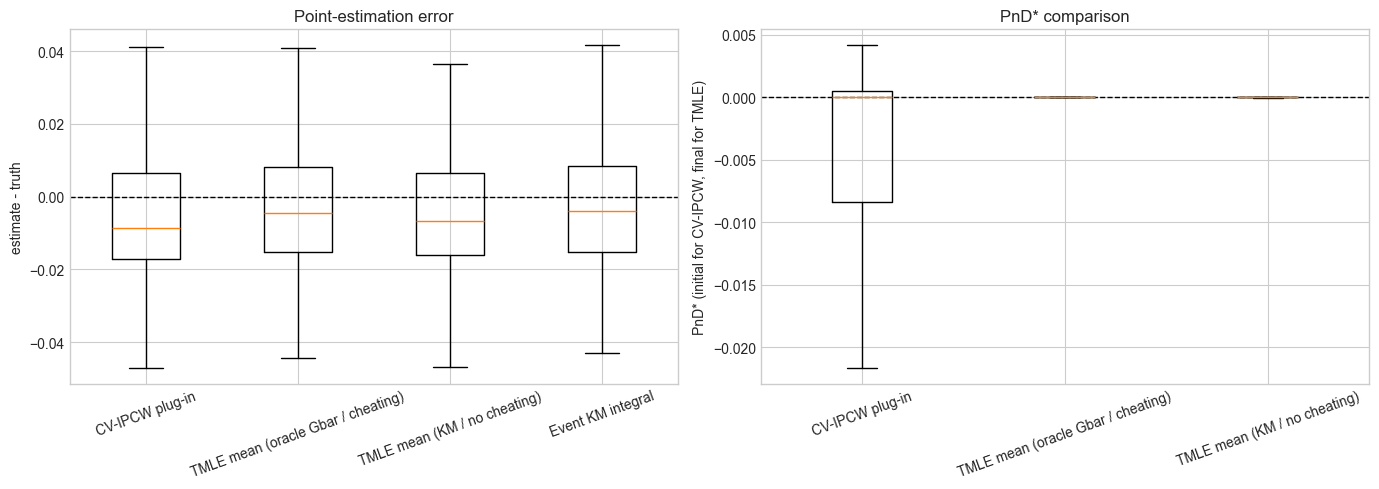

In [8]:
mc_summary = summarize_mc(mc_results)

tmle_results = mc_results[mc_results["method"].str.startswith("TMLE")].copy()
run_diagnostics = pd.DataFrame([
    {
        "n_seeds": int(mc_results["seed"].nunique()),
        "n_rows": int(len(mc_results)),
        "n_tmle_rows": int(len(tmle_results)),
        "n_converged_tmle": int(tmle_results["converged"].sum()),
        "n_not_converged_tmle": int((~tmle_results["converged"]).sum()),
        "median_iterations_tmle": float(tmle_results["n_iterations"].median()),
        "median_runtime_seconds": float(mc_results["runtime_seconds"].median()),
        "n_tmle_rows_with_eic_exclusions": int((tmle_results["eic_excluded_count"] > 0).sum()),
        "median_tmle_eic_excluded_rate": float(tmle_results["eic_excluded_rate"].median()),
        "mean_censoring_rate": float(mc_results["censoring_rate"].mean()),
        "median_max_ipcw_weight": float(mc_results["max_ipcw_weight"].median()),
        "max_abs_pnd_star": float(np.nanmax(np.abs(mc_results["pnd_star"]))),
    }
])

display(mc_summary)
display(run_diagnostics)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

method_order = [
    "CV-IPCW plug-in",
    "TMLE mean (oracle Gbar / cheating)",
    "TMLE mean (KM / no cheating)",
    "Event KM integral",
]

error_data = [
    mc_results.loc[mc_results["method"] == method, "error"].to_numpy(dtype=float)
    for method in method_order
]
axes[0].boxplot(error_data, labels=method_order, showfliers=False)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Point-estimation error")
axes[0].set_ylabel("estimate - truth")
axes[0].tick_params(axis="x", rotation=20)

score_methods = [
    "CV-IPCW plug-in",
    "TMLE mean (oracle Gbar / cheating)",
    "TMLE mean (KM / no cheating)",
]
score_data = [
    mc_results.loc[mc_results["method"] == method, "pnd_star"].to_numpy(dtype=float)
    for method in score_methods
]
axes[1].boxplot(score_data, labels=score_methods, showfliers=False)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("PnD* comparison")
axes[1].set_ylabel("PnD* (initial for CV-IPCW, final for TMLE)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()
